In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('..')
from mount_drive import mount_s_drive

ModuleNotFoundError: No module named 'mount_drive'

In [ ]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), 'analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

In [271]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [272]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia',
       'FirstGCSTime', 'FirstGCS', 'LastGCSTime', 'LastGCS', 'Troponin',
       'Lactate', 'pH', 'Chloride', 'hospitaldischargestatus',
       'DeathAtDischarge', 'LastGCS15'],
      dtype='object')

In [278]:
myBestModel.named_steps

{'preprocessor': ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore',
                                           sparse_output=False),
                   transformers=[('num', StandardScaler(),
                                  Index(['age', 'admissionheight', 'admissionweight', 'FirstGCS', 'Troponin',
        'Lactate', 'pH', 'Chloride'],
       dtype='object')),
                                 ('bin', 'passthrough',
                                  Index(['gender', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia',
        'LastGCSPositive'],
       dtype='object'))]),
 'imputer': SimpleImputer(),
 'pca': PCA(n_components=0.95),
 'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type

In [274]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)

In [284]:
myXValue = myPredictorsDf.drop(columns= ['LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastGCS']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCSPositive', 'Hypothermia']], test_size=0.30)

In [285]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='r2')
myBestModel = myGridSearchCv.best_estimator_

/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

Best parameters: {'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 2, 'clf__n_estimators': 10}
Best cross val r2 score: 0.2823
R2 score    on test set: 0.2801564505198818


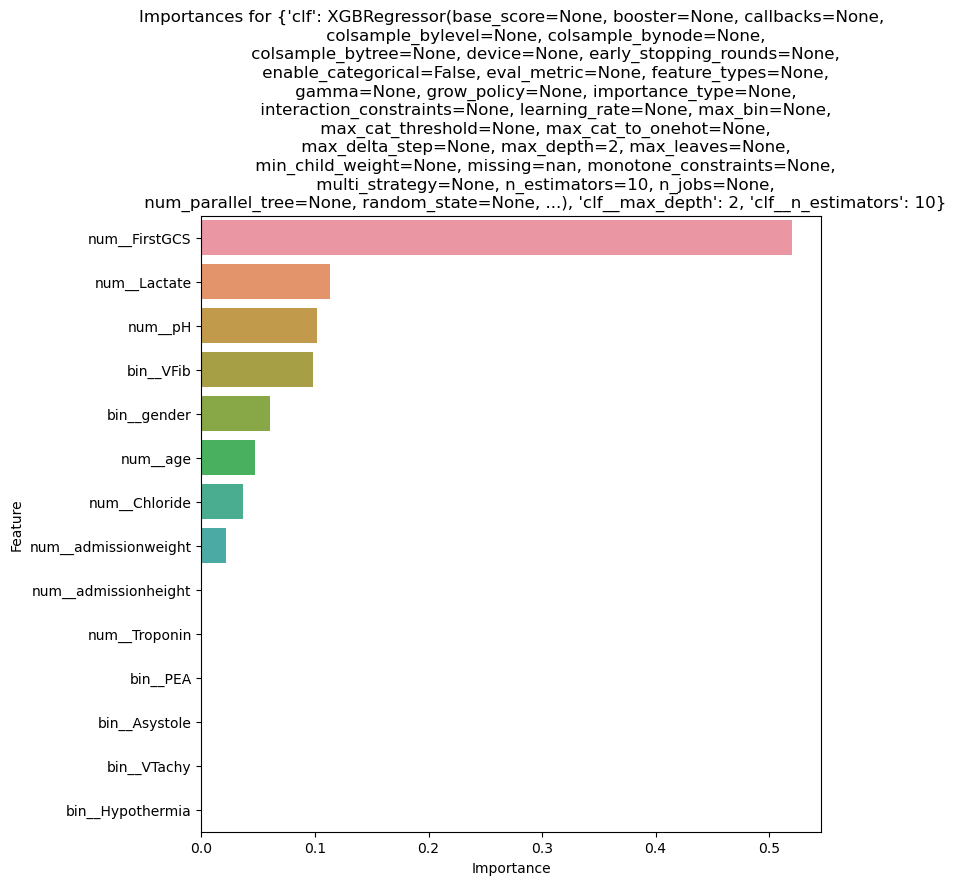

In [286]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [288]:
def getTreatmentEffectDiff_regression(X_train, y_train, myNewDf, aCategory='CPC12', aGroup='groupe'):
    # Combine the relevant data into one DataFrame
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    myData = myData.rename(columns={y_train.name: aCategory})  # Ensure the target column is named consistently

    # Fit the reduced model (without interaction term)
    model1 = smf.ols(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    # Fit the full model (with interaction term)
    model2 = smf.ols(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    # Perform an F-test to compare the models
    f_stat = (model1.ssr - model2.ssr) / (model2.df_model - model1.df_model) / (model2.ssr / model2.df_resid)
    df_diff = model2.df_model - model1.df_model
    p_value = f.sf(f_stat, df_diff, model2.df_resid)

    print(f'Likelihood ratio of test results (F-test for regression):')
    print(f'F-statistic: {f_stat}')
    print(f'p-value: {p_value}')
    print(f'Degrees of freedom: {df_diff}')
    print(f'model1: {model1.summary()}')
    print(f'model2: {model2.summary()}')
    return p_value

In [289]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
myNewDf = pd.DataFrame()
myNewDf['predicted_effect_group'] = myBestModel.predict(X_test)
getTreatmentEffectDiff_regression(X_test, y_test, myNewDf, 'LastGCS', 'Hypothermia')

Likelihood ratio of test results (F-test for regression):
F-statistic: 3.312992876132548
p-value: 0.06986221116670936
Degrees of freedom: 1.0
model1:                             OLS Regression Results                            
Dep. Variable:                LastGCS   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.239
Date:                Sun, 29 Dec 2024   Prob (F-statistic):              0.109
Time:                        20:10:09   Log-Likelihood:                -809.56
No. Observations:                 269   AIC:                             1625.
Df Residuals:                     266   BIC:                             1636.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t     

0.06986221116670936

In [14]:
def getPredictedThirds(aDf):
    lower_third = aDf['predicted_effect'].quantile(1/3)
    upper_third = aDf['predicted_effect'].quantile(2/3)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1, 1, aDf
    aDf['predicted_effect_group'] = pd.cut(
        aDf['predicted_effect'],
        bins=[-float('inf'), lower_third, upper_third, float('inf')],
        labels=['Lower', 'Middle', 'Upper']
    )
    # aDf['predicted_effect_group'] = (aDf['predicted_effect'] > 0).astype(int)
    return lower_third, upper_third, aDf

def getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup):
    myXValueModified1 = X_train.copy()
    myXValueModified1[aGroup] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2[aGroup] = 0.0
    if hasattr(aModel, 'predict_proba'):
        y_pred_proba1 = aModel.predict_proba(myXValueModified1)[:, 1]
        y_pred_proba2 = aModel.predict_proba(myXValueModified2)[:, 1]
    else:
        y_pred_proba1 = aModel.predict(myXValueModified1)
        y_pred_proba2 = aModel.predict(myXValueModified2)
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect'] = (y_pred_proba1 - y_pred_proba2)
    return plotPredictedTreatmentEffect(myNewDf=myNewDf, aCategory=aCategory)
    

def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'Interaction p-value: {model1.summary()}')
    return p_value
def getTreatmentEffectDiffUnsupervised(aX, aY, aGroups, aCategory = 'CPC12', aGroup = 'groupe'):
        myNewDf = pd.DataFrame()
        myNewDf['predicted_effect_group'] = aGroups
        myData = pd.concat([aX[aGroup], myNewDf['predicted_effect_group'], aY], axis=1)
        model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
        ).fit()

        model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
        ).fit()

        llr = -2*(model1.llf - model2.llf)
        df_diff = model2.df_model - model1.df_model
        p_value = chi2.sf(llr, df_diff)

        print(f'Likelihood ratio of test results:')
        print(f'Chi square statistic: {llr}')
        print(f'p-value: {p_value}')
        print(f'Degress of freedom: {df_diff}')
        print(f'Interaction p-value: {model2.summary()}')
        return p_value, model2, myData
def plotPredictedEffectDiff(aData, aBestModel, aCategory = 'CPC12', aGroup = 'groupe'):
    predicted_effect_groups = aData['predicted_effect_group'].unique()
    predicted_effect_groups.sort()
    groupe_values = aData[aGroup].unique()
    groupe_values.sort()
    groupe_values = list(filter(lambda x: not np.isnan(x), groupe_values))
    
    predicted_effect_groups = list(filter(lambda x: not np.isnan(x), predicted_effect_groups))

    # Prepare the DataFrame for prediction
    predictions = []
    for groupe in groupe_values:
            for effect in predicted_effect_groups:
                    temp_df = pd.DataFrame({
                            'predicted_effect_group': [effect],
                            aGroup: [groupe]
                    })
                    # Predict the probability
                    temp_df['predicted_prob'] = aBestModel.predict(temp_df)
                    predictions.append(temp_df)

    # Concatenate all predictions
    predictions_df = pd.concat(predictions)
    
    # Create a bar plot
    plt.figure(figsize=(8, 6))
    for i, groupe in enumerate(groupe_values):
            subset = predictions_df[predictions_df[aGroup] == groupe]
            plt.bar(
                    subset['predicted_effect_group'] + (i * 0.2) - 0.1,    # Shift bars slightly for better visualization
                    subset['predicted_prob'],
                    width=0.2,
                    label=f'Groupe {groupe}'
            )
            
    x_positions = np.arange(len(predicted_effect_groups)) 

    plt.xticks(x_positions)
    plt.xlabel('Predicted Effect Group')
    plt.ylabel(f'Predicted Probability of {aCategory}')
    plt.title(f'Predicted Probability of {aCategory} by Predicted Effect Group and Groupe')
    plt.legend(title='Groupe')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')
    return lower_third, upper_third, myNewDf

Optimization terminated successfully.
         Current function value: 0.652546
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.651884
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 2.0095965471900854
p-value: 0.15630688084875557
Degress of freedom: 1.0
Interaction p-value:                            Logit Regression Results                           
Dep. Variable:              LastGCS15   No. Observations:                 1517
Model:                          Logit   Df Residuals:                     1513
Method:                           MLE   Df Model:                            3
Date:                Sun, 29 Dec 2024   Pseudo R-squ.:                0.004001
Time:                        11:12:59   Log-Likelihood:                -988.91
converged:                       True   LL-Null:                       -992.88
Covariance Type:            nonrobust   LLR p-value:                   0.04716
               

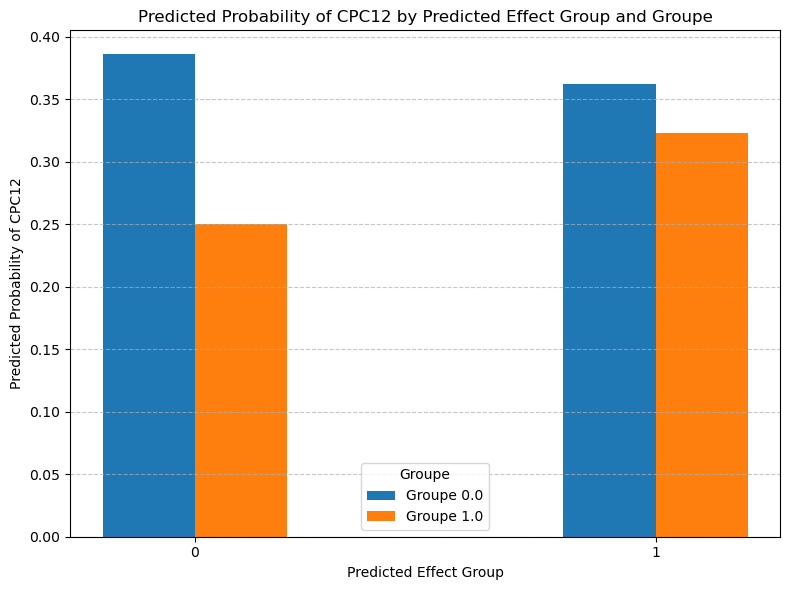

In [41]:
myXInput = X_train.copy()
myClassifierTest = 'LastGCS15'
myYInput = myPredictorsDf[myFilter][myClassifierTest].copy()
myNewXValue = myXInput.copy()
myNewXValue = myNewXValue.drop(columns=['Hypothermia'])
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', AgglomerativeClustering(n_clusters=2)))
myPipeline = Pipeline(myPipelineSteps)
myGroups = myPipeline.fit_predict(myNewXValue)
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXInput, myYInput, myGroups, myClassifierTest, 'Hypothermia')
print(f'Silhouette score of clusters: {silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups)}')
plotPredictedEffectDiff(aData = myData, aBestModel = myModel, aGroup = 'Hypothermia')



In [38]:
myGroups

array([0, 1, 1, ..., 0, 1, 1])

Fitting StepMix...


Initializations (n_init) : 100% 10/10 [00:05<00:00,  1.85it/s, max_LL=-1.97e+4, max_avg_LL=-6.09]


Optimization terminated successfully.
         Current function value: 0.650965
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.650671
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.7955955666925547
p-value: 0.18024588273321462
Degress of freedom: 1.0
Interaction p-value:                            Logit Regression Results                           
Dep. Variable:              LastGCS15   No. Observations:                 3061
Model:                          Logit   Df Residuals:                     3057
Method:                           MLE   Df Model:                            3
Date:                Sun, 15 Dec 2024   Pseudo R-squ.:                0.004215
Time:                        18:59:07   Log-Likelihood:                -1991.7
converged:                       True   LL-Null:                       -2000.1
Covariance Type:            nonrobust   LLR p-value:                 0.0007545
               

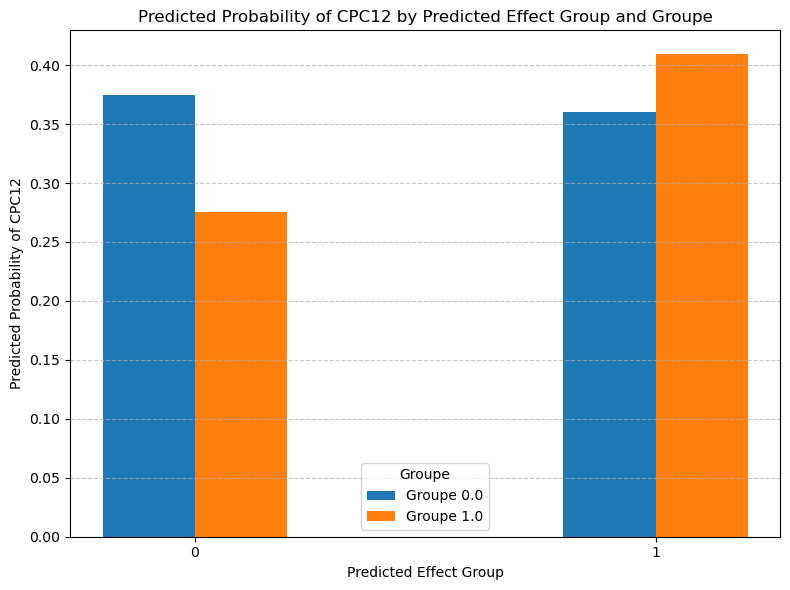

0.37700833437242376


In [493]:
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['Hypothermia'])
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', StepMix(n_components=2, n_init=10, measurement="categorical")))
myPipeline = Pipeline(myPipelineSteps)
myPipeline.fit(myNewXValue)
myGroups = myPipeline.predict(myNewXValue)
myClassifierTest = 'LastGCS15'
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXValue, myPredictorsDf[myFilter][myClassifierTest], myGroups, myClassifierTest, 'Hypothermia')
plotPredictedEffectDiff(aData = myData, aBestModel = myModel, aGroup = 'Hypothermia')
print(silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups))

In [242]:
from econml.dml import CausalForestDML
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['Hypothermia'])
myYValue = myPredictorsDf[myFilter]['DeathAtDischarge']
myYValue = myYValue.astype(int)
X_train_no_group, X_test_no_group, T_train, T_test, Y_train, Y_test = train_test_split(myNewXValue, myPredictorsDf[myFilter]['Hypothermia'], myYValue, test_size=0.5, stratify=myPredictorsDf[myFilter][['DeathAtDischarge', 'Hypothermia']])
causal_forest = CausalForestDML(
    model_t=RandomForestClassifier(),    # Model to predict treatment
    model_y=RandomForestClassifier(),    # Model to predict outcome
    n_estimators=100,                   # Number of trees in the forest
    min_samples_leaf=5,
    max_depth=5,
    discrete_treatment=True,            # Indicate binary treatment
    discrete_outcome=True,
)
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 10) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', SimpleImputer(missing_values=np.nan, strategy='mean'))]
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))
myNewXTrain = myPipeline.fit_transform(X_train_no_group)
causal_forest.fit(Y_train, T_train, X=myNewXTrain, cache_values=True)


myNewXTest = myPipeline.transform(X_train_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

Feature importances [9.80437999e-02 1.00278249e-01 1.32264199e-01 2.13260427e-01
 8.02116516e-02 9.78050749e-02 1.40302219e-01 1.13406184e-01
 7.73308272e-03 1.42486943e-04 8.85589155e-03 7.69673413e-03
 0.00000000e+00]
Predicted CATE for test data: [[-0.00237612]
 [ 0.03555682]
 [-0.01338108]
 [-0.04720291]
 [-0.04764129]
 [ 0.05830284]
 [ 0.03401782]
 [-0.00692996]
 [ 0.02851982]
 [-0.09861936]]


In [243]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate              
===============================================================
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.008       0.089 0.086  0.932        -0.166         0.182
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.057          -0.082           0.136
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.105         -0.188          0.235
       Doubly Robust ATE on Training Data Results       
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.031  0.042 0.738  0.461   -0.052    0.114
    Doubly Robust ATT(T=0) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT           0.01  0.015  0.69   0.49   -0.019     0.04
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT           0.14  0.251 0.557  0.578   -0.352    0.632
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

In [206]:
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')

In [214]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect'] = (myNewDf['predicted_effect'] > 0).astype(int)

-0.009354853912587816
0.02436311950292458


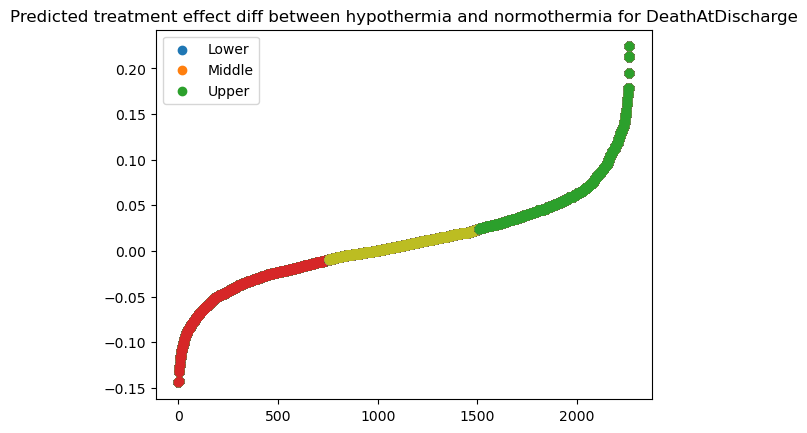

In [215]:
plotPredictedTreatmentEffect(myNewDf, 'DeathAtDischarge')

In [216]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12', aGroup = 'groupe'):
    if X_train.shape[0] != y_train.shape[0]:
        raise Exception('Mismatch X and Y')
    if X_train.shape[0] != myNewDf.shape[0]:
        raise Exception('Mismatch group and X')
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)
    
    myPvaluesNoInteraction = model1.summary()
    myPvalues = model2.summary()

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'No interaction {myPvaluesNoInteraction}')
    print(f'Interaction {myPvalues}')
    return p_value
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import f



In [245]:
# getTreatmentEffectDiff_regression(X_train, myYValue, myNewDf, 'LastGCS', 'Hypothermia')
myNewXTest = myPipeline.transform(X_train_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
# myNewDf['predicted_effect'] = CATE_pred[:, 0]
# # myNewDf['predicted_effect']
# lower_third, upper_third, _ = getPredictedThirds(myNewDf)
# plotPredictedTreatmentEffect(myNewDf, 'DeathAtDischarge')

myNewDf['predicted_effect_group'] = CATE_pred[:, 0]


X_test_new = X_train_no_group.copy()
X_test_new['Hypothermia'] = T_train
getTreatmentEffectDiff(X_test_new, Y_train, myNewDf, 'DeathAtDischarge', 'Hypothermia')

Optimization terminated successfully.
         Current function value: 0.691838
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.689547
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 3.4266001268058517
p-value: 0.1802699078036839
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  748
Model:                          Logit   Df Residuals:                      746
Method:                           MLE   Df Model:                            1
Date:                Sun, 29 Dec 2024   Pseudo R-squ.:               0.0003989
Time:                        16:40:40   Log-Likelihood:                -517.49
converged:                       True   LL-Null:                       -517.70
Covariance Type:            nonrobust   LLR p-value:                    0.5204
                      

0.1802699078036839

In [246]:
myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect_group'] = CATE_pred[:, 0]
# myNewDf['predicted_effect_group'] = 'Middle'
# myNewDf.loc[myNewDf['predicted_effect'] > upper_third, 'predicted_effect_group'] = 'Upper'
# myNewDf.loc[myNewDf['predicted_effect'] < lower_third, 'predicted_effect_group'] = 'Lower'
# plotPredictedTreatmentEffect(myNewDf, 'DeathAtDischarge')

X_test_new = X_test_no_group.copy()
X_test_new['Hypothermia'] = T_test
getTreatmentEffectDiff(X_test_new, Y_test, myNewDf, 'DeathAtDischarge', 'Hypothermia')

Optimization terminated successfully.
         Current function value: 0.692265
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.691082
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 1.8550962680303655
p-value: 0.39552229012188644
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  784
Model:                          Logit   Df Residuals:                      782
Method:                           MLE   Df Model:                            1
Date:                Sun, 29 Dec 2024   Pseudo R-squ.:                0.001043
Time:                        16:41:04   Log-Likelihood:                -542.74
converged:                       True   LL-Null:                       -543.30
Covariance Type:            nonrobust   LLR p-value:                    0.2871
                     

0.39552229012188644

In [197]:
def getPredictedThirds(aDf):
    lower_third = aDf['predicted_effect'].quantile(1/3)
    upper_third = aDf['predicted_effect'].quantile(2/3)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1, 1, aDf
    aDf['predicted_effect_group'] = pd.cut(
        aDf['predicted_effect'],
        bins=[-float('inf'), lower_third, upper_third, float('inf')],
        labels=['Lower', 'Middle', 'Upper']
    )
    # aDf['predicted_effect_group'] = (aDf['predicted_effect'] > 0).astype(int)
    print(lower_third)
    print(upper_third)
    return lower_third, upper_third, aDf

In [179]:
getPredictedThirds(myNewDf)

(-0.010620518605374545,
 0.04578572565981268,
      index  predicted_effect predicted_effect_group
 0      590         -0.243377                  Lower
 1      885         -0.218819                  Lower
 2      337         -0.195290                  Lower
 3      921         -0.182073                  Lower
 4      391         -0.178665                  Lower
 ..     ...               ...                    ...
 965    660          0.203959                  Upper
 966    205          0.210693                  Upper
 967    374          0.241779                  Upper
 968     94          0.250243                  Upper
 969    965          0.256729                  Upper
 
 [970 rows x 3 columns])

In [235]:
causal_forest.summary()

Population summary results are available only if `cache_values=True` at fit time!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATE,0.004,0.044,0.103,0.918,-0.081,0.09
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATT,0.0,0.013,0.029,0.977,-0.025,0.025
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATT,0.026,0.264,0.099,0.921,-0.491,0.543
